In [79]:
#source activate newEnv
suppressMessages(library(dplyr))
suppressMessages(library(ggplot2))
library(tibble)
library(broom)
library("parallel")
library(tidyr)
library(stringr)
library(qvalue)

Warning message:
“package ‘qvalue’ was built under R version 4.4.2”


In [32]:
cells <- scan('/nfs/lab/tscc/rlmelton/liver_HOMER/liver_data/listofcells.txt', what="", sep="\n")
cells <- cells[cells != 'Bulk']
cells

[1] "B"             "Cholangiocyte" "Endothelial"   "Hepatocytes"  
 [5] "HSC"           "Mast"          "Myeloid"       "NK"           
 [9] "Schwann"       "T"

# Save GRN beds

In [6]:
grns <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/SCENIC/Hepatocytes/eRegulon_direct.tsv', header=T)

dim(grns)
head(grns)

[1] 35155    15

,Region,Gene,importance_R2G,rho_R2G,importance_x_rho,importance_x_abs_rho,TF,is_extended,eRegulon_name,Gene_signature_name,Region_signature_name,importance_TF2G,regulation,rho_TF2G,triplet_rank
,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<int>,<dbl>,<int>
1,chr4:73965001-73965301,CXCL2,0.02447437,0.12776317,0.003126923,0.003126923,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),1.7770506,1,0.19948248,15869
2,chr3:189383753-189384053,TPRG1,0.01759522,0.10194220,0.001793696,0.001793696,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),3.2928309,1,0.38799972,3467
3,chr16:30844748-30845048,ORAI3,0.10015906,0.05560605,0.005569450,0.005569450,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),1.2935095,1,0.07809416,11437
4,chr8:26693755-26694055,ADRA1A,0.02128050,0.25861542,0.005503467,0.005503467,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),3.0368573,1,0.38357860,2867
5,chr4:68963470-68963770,UGT2B7,0.09891115,0.16103632,0.015928288,0.015928288,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),2.5326155,1,0.18274981,1052
6,chrX:53086539-53086808,KANTR,0.19290936,0.08702135,0.016787234,0.016787234,AR,False,AR_direct_+/+,AR_direct_+/+_(47g),AR_direct_+/+_(54r),0.7767084,1,0.19450613,222


In [7]:
length(unique(grns$Region))

[1] 19388

In [13]:
MASH_GRNs <- c('CREB5_direct_+/+','E2F3_direct_+/+','ETS1_direct_+/+','FLI1_direct_+/+','GATAD2A_direct_+/+',
              'RELB_direct_+/+','NFKB1_direct_+/+','KLF6_direct_+/+','MBD2_direct_+/+','RB1_direct_+/+',
              'FOXK1_direct_+/+','PPARD_direct_+/+','ELF3_direct_+/+','RUNX1_direct_+/+','HMGXB3_direct_+/+',
              'ZBTB7A_direct_+/+','NFAT5_direct_+/+','ERG_direct_+/+','ETS2_direct_+/+','TEAD1_direct_+/+',
              'ZNF654_direct_+/+','NFATC2_direct_+/+','CUX1_direct_+/+','ZNF644_direct_+/+','ELK4_direct_+/+',
              'IKZF1_direct_+/+','ETV5_direct_+/+','TBL1XR1_direct_+/+','ELF1_direct_+/+','CHD2_direct_+/+',
              'GABPB1_direct_+/+','PHF20_direct_+/+','PHF20_direct_+/+','ZBTB21_direct_+/+','RXRA_direct_+/+',
              'SREBF2_direct_+/+')
MASL_GRNs <- c('NR1I2_direct_+/+','TFDP2_direct_+/+','HNF4A_direct_+/+','KLF13_direct_+/+','AR_direct_+/+',
              'KLF12_direct_+/+','NR3C2_direct_+/+','CUX2_direct_+/+','ZBTB20_direct_+/+','RORA_direct_+/+')

length(MASH_GRNs)
sum(MASH_GRNs %in% grns$eRegulon_name)

length(MASL_GRNs)
sum(MASL_GRNs %in% grns$eRegulon_name)

[1] 36

[1] 36

[1] 10

[1] 10

In [19]:
grns %>%
    filter( eRegulon_name %in% MASH_GRNs) %>%
    select(Region) %>%
    unlist() %>%
    str_split(':|-', simplify=T) %>%
    write.table('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_MASH_GRN_Features.bed',
               sep='\t', col.names=F, row.names=F, quote=F)

In [20]:
grns %>%
    filter( eRegulon_name %in% MASL_GRNs) %>%
    select(Region) %>%
    unlist() %>%
    str_split(':|-', simplify=T) %>%
    write.table('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_MASL_GRN_Features.bed',
               sep='\t', col.names=F, row.names=F, quote=F)

In [21]:
grns %>%
    select(Region) %>%
    unlist() %>%
    str_split(':|-', simplify=T) %>%
    write.table('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/background/241221_WE_GRN_Features.bed',
               sep='\t', col.names=F, row.names=F, quote=F)

# H3K27me3 sites

In [22]:
# Setup directories
traits.dir = "/nfs/lab/FinnGen_R11/finemap/summary/"
finrich.dir = '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/'

In [23]:
deseq.outdir <- '/nfs/lab/projects/nash_nafld_liver/downstream_all/09_H3K27me3_DESEQ/15kb_bins/'
bed.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/'

In [24]:
list.files(deseq.outdir, pattern='.dds.res')

[1] "B_Age.dds.res"                             
 [2] "B_Age.scaled.dds.res"                      
 [3] "B_BMI.dds.res"                             
 [4] "B_BMI.scaled.dds.res"                      
 [5] "B_Fibrosis.stage.dds.res"                  
 [6] "B_Lobular.inflammation.dds.res"            
 [7] "B_MASH_ALL_vs_Control.dds.res"             
 [8] "B_MASH_vs_Control.dds.res"                 
 [9] "B_MASH.CRN.score..X.8.dds.res"             
[10] "B_MASL_vs_Control.dds.res"                 
[11] "B_MetALD_vs_Control.dds.res"               
[12] "B_Steatosis.grade.dds.res"                 
[13] "Cholangiocyte_Age.dds.res"                 
[14] "Cholangiocyte_Age.scaled.dds.res"          
[15] "Cholangiocyte_BMI.dds.res"                 
[16] "Cholangiocyte_BMI.scaled.dds.res"          
[17] "Cholangiocyte_Fibrosis.stage.dds.res"      
[18] "Cholangiocyte_Lobular.inflammation.dds.res"
[19] "Cholangiocyte_MASH_ALL_vs_Control.dds.res" 
[20] "Cholangiocyte_MASH_vs_Control.dds.res"     
[21] "Cholangiocyte_MASH.CRN.score..X.8.dds.res" 
[22] "Cholangiocyte_MASL_vs_Control.dds.res"     
[23] "Cholangiocyte_MetALD_vs_Control.dds.res"   
[24] "Cholangiocyte_Steatosis.grade.dds.res"     
[25] "Endothelial_Age.dds.res"                   
[26] "Endothelial_Age.scaled.dds.res"            
[27] "Endothelial_BMI.dds.res"                   
[28] "Endothelial_BMI.scaled.dds.res"            
[29] "Endothelial_Fibrosis.stage.dds.res"        
[30] "Endothelial_Lobular.inflammation.dds.res"  
[31] "Endothelial_MASH_ALL_vs_Control.dds.res"   
[32] "Endothelial_MASH_vs_Control.dds.res"       
[33] "Endothelial_MASH.CRN.score..X.8.dds.res"   
[34] "Endothelial_MASL_vs_Control.dds.res"       
[35] "Endothelial_MetALD_vs_Control.dds.res"     
[36] "Endothelial_Steatosis.grade.dds.res"       
[37] "Hepatocytes_Age.dds.res"                   
[38] "Hepatocytes_Age.scaled.dds.res"            
[39] "Hepatocytes_BMI.dds.res"                   
[40] "Hepatocytes_BMI.scaled.dds.res"            
[41] "Hepatocytes_Fibrosis.stage.dds.res"        
[42] "Hepatocytes_Lobular.inflammation.dds.res"  
[43] "Hepatocytes_MASH_ALL_vs_Control.dds.res"   
[44] "Hepatocytes_MASH_vs_Control.dds.res"       
[45] "Hepatocytes_MASH.CRN.score..X.8.dds.res"   
[46] "Hepatocytes_MASL_vs_Control.dds.res"       
[47] "Hepatocytes_MetALD_vs_Control.dds.res"     
[48] "Hepatocytes_Steatosis.grade.dds.res"       
[49] "HSC_Age.dds.res"                           
[50] "HSC_Age.scaled.dds.res"                    
[51] "HSC_BMI.dds.res"                           
[52] "HSC_BMI.scaled.dds.res"                    
[53] "HSC_Fibrosis.stage.dds.res"                
[54] "HSC_Lobular.inflammation.dds.res"          
[55] "HSC_MASH_ALL_vs_Control.dds.res"           
[56] "HSC_MASH_vs_Control.dds.res"               
[57] "HSC_MASH.CRN.score..X.8.dds.res"           
[58] "HSC_MASL_vs_Control.dds.res"               
[59] "HSC_MetALD_vs_Control.dds.res"             
[60] "HSC_Steatosis.grade.dds.res"               
[61] "Myeloid_Age.dds.res"                       
[62] "Myeloid_Age.scaled.dds.res"                
[63] "Myeloid_BMI.dds.res"                       
[64] "Myeloid_BMI.scaled.dds.res"                
[65] "Myeloid_Fibrosis.stage.dds.res"            
[66] "Myeloid_Lobular.inflammation.dds.res"      
[67] "Myeloid_MASH_ALL_vs_Control.dds.res"       
[68] "Myeloid_MASH_vs_Control.dds.res"           
[69] "Myeloid_MASH.CRN.score..X.8.dds.res"       
[70] "Myeloid_MASL_vs_Control.dds.res"           
[71] "Myeloid_MetALD_vs_Control.dds.res"         
[72] "Myeloid_Steatosis.grade.dds.res"           
[73] "NK_Age.dds.res"                            
[74] "NK_Age.scaled.dds.res"                     
[75] "NK_Ballooning.dds.res"                     
[76] "NK_BMI.dds.res"                            
[77] "NK_BMI.scaled.dds.res"                     
[78] "NK_Fibrosis.stage.dds.res"                 
[79] "NK_Lobular.inflammation.dds.res"           
[80] "NK_MASH_ALL_vs_Control.dds.res"            
[

In [25]:
for (file in list.files(deseq.outdir, pattern='.dds.res')) {
    cell <- str_split_fixed(string = file, pattern = '_', n = 2)[1]
    contrast <- str_split_fixed(string = file, pattern = '_', n = 2)[2]
    if (contrast %in% c('Age.dds.res', 'Age.scaled.dds.res','BMI.dds.res', 'BMI.scaled.dds.res',
                       'Lobular.inflammation.dds.res', 'MASH.CRN.score..X.8.dds.res', 
                       'MASH_vs_Control.pseudocount.dds.res','MASL_vs_Control.pseudocount.dds.res',
                        'MetALD_vs_Control.pseudocount.dds.res')) {
        next
    }
    if (cell == 'Bulk') {
        next
    }
    print(paste0(cell, ":", contrast))
    
    res <- read.table(paste0(deseq.outdir, file))
    res <- distinct(res)
    
    if (nrow(filter(res, pvalue < 0.05 & log2FoldChange < 0)) > 0) {
        write.table(str_split(unique(rownames(filter(res, pvalue < 0.05 & log2FoldChange < 0))), "[-:]", simplify=T),
                paste0(bed.dir, 'H3K27me3_15kbbins.', file, '.nominal.down.bed'), sep='\t', col.names=F, row.names=F, quote=F)
    }
    if (nrow(filter(res, pvalue < 0.05 & log2FoldChange > 0)) > 0) {
        write.table(str_split(unique(rownames(filter(res, pvalue < 0.05 & log2FoldChange > 0))), "[-:]", simplify=T),
                paste0(bed.dir, 'H3K27me3_15kbbins.', file, '.nominal.up.bed'), sep='\t', col.names=F, row.names=F, quote=F)
    }
    
    if (nrow(filter(res, padj < 0.05 & log2FoldChange < 0)) > 0) {
        write.table(str_split(unique(rownames(filter(res, padj < 0.05 & log2FoldChange < 0))), "[-:]", simplify=T),
                paste0(bed.dir, 'H3K27me3_15kbbins.', file, '.padj.down.bed'), sep='\t', col.names=F, row.names=F, quote=F)
    }
    if (nrow(filter(res, padj < 0.05 & log2FoldChange > 0)) > 0) {
        write.table(str_split(unique(rownames(filter(res, padj < 0.05 & log2FoldChange > 0))), "[-:]", simplify=T),
                paste0(bed.dir, 'H3K27me3_15kbbins.', file, '.padj.up.bed'), sep='\t', col.names=F, row.names=F, quote=F)
    }
}

[1] "B:Fibrosis.stage.dds.res"
[1] "B:MASH_ALL_vs_Control.dds.res"
[1] "B:MASH_vs_Control.dds.res"
[1] "B:MASL_vs_Control.dds.res"
[1] "B:MetALD_vs_Control.dds.res"
[1] "B:Steatosis.grade.dds.res"
[1] "Cholangiocyte:Fibrosis.stage.dds.res"
[1] "Cholangiocyte:MASH_ALL_vs_Control.dds.res"
[1] "Cholangiocyte:MASH_vs_Control.dds.res"
[1] "Cholangiocyte:MASL_vs_Control.dds.res"
[1] "Cholangiocyte:MetALD_vs_Control.dds.res"
[1] "Cholangiocyte:Steatosis.grade.dds.res"
[1] "Endothelial:Fibrosis.stage.dds.res"
[1] "Endothelial:MASH_ALL_vs_Control.dds.res"
[1] "Endothelial:MASH_vs_Control.dds.res"
[1] "Endothelial:MASL_vs_Control.dds.res"
[1] "Endothelial:MetALD_vs_Control.dds.res"
[1] "Endothelial:Steatosis.grade.dds.res"
[1] "Hepatocytes:Fibrosis.stage.dds.res"
[1] "Hepatocytes:MASH_ALL_vs_Control.dds.res"
[1] "Hepatocytes:MASH_vs_Control.dds.res"
[1] "Hepatocytes:MASL_vs_Control.dds.res"
[1] "Hepatocytes:MetALD_vs_Control.dds.res"
[1] "Hepatocytes:Steatosis.grade.dds.res"
[1] "HSC:Fibrosis.st

#### Background set

In [33]:
back.bed.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/background/'
# Get TSS sites
for (c in cells) {
    peak.tab <- read.table(paste0('/nfs/lab/tscc/welison/FNIH.Liver/DPT.files/bins_mtx/',c,'_H3K27me3_donor.15kb_bin.rpm.xls')) %>%
        rownames() %>%
        str_split('-|:', simplify=T) %>%
        as.data.frame()
    write.table(distinct(peak.tab), paste0(back.bed.dir,'H3K27me3_15kbbins.',c,'_background.bed'), 
                quote=F, col.names=F, row.names=F, sep='\t')
}

# Write FINRICH commands

In [43]:
diseases= c('Fibrosis.stage', 'MASH_ALL_vs_Control', 'MASH_vs_Control', 'MASL_vs_Control', 'MetALD_vs_Control','fibrosis')
modalities <- c('H3K27me3_15kbbins')
grn <- c('MASH','MASL')
direction <- c('up','down')
sig_level <- c('nominal','padj')
cluster_groups <- c('MASH_up','MASH_down','MASH','MASL_up','MASL_down','MASL','MetALD_up','MetALD_down','MetALD')

trait_beds <- rev(list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits/', full.names = TRUE)) #full.names makes sure you have the full file path
background_beds <- list.files('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/background/', full.names = TRUE)
bed.dir <- '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/sites/'

celltypes <- c('B','Cholangiocyte','Endothelial','Hepatocytes','HSC','Mast','Myeloid','NK','Schwann','T')

In [38]:
#dir.create('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/')

In [39]:
setwd('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/')

In [40]:
head(trait_beds)

[1] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed"
[2] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.EUR.MVP.2021.credset.bed"  
[3] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T2D_WIDE_Hg38.bed"       
[4] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T2D_Hg38.bed"            
[5] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T1D_Hg38.bed"            
[6] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//finngen_R11_T1D_EARLY_Hg38.bed"

In [41]:
out.dir <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/'

In [58]:
Sys.time()
commands <- character()

# Run for DE sites
for(FILE in trait_beds[1]){
    cs_file <- str_replace(FILE, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')#paste0(sprintf('/nfs/lab/projects/nash_nafld_liver/downstream_all/11_FINRICH/background/%s.spec.union.peaks.bed',
    results2 <- NULL #Create an empty dataframe to store results from loop
    message(FILE)

    for(MOD in modalities){
        message(MOD)

        for(DIRECT in direction){
            message(DIRECT)
            for(SIG in sig_level){
                message(SIG)
                for (CELL in cells){
                    #message(CELL)
                    for (disease_num in 1:length(diseases)){
                        input_name <- paste0(sprintf('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/%s.%s_%s.dds.res.%s.%s.bed', MOD, CELL,diseases[disease_num],SIG, DIRECT))
                        if (file.exists(str_replace(input_name, '/tscc/projects/ps-gaultonlab','/nfs/lab/tscc'))) {
                            
                            if(MOD %in% c('H3K27ac','H3K27me3','H3K27ac_ATAC_Peaks','H3K27me3_ATAC_Peaks','H3K27ac_TSS','H3K27me3_TSS','H3K27me3_15kbbins')){
                                background_name <- paste0(sprintf('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/%s.%s_background.bed', MOD, CELL))
    
                            }else if (MOD %in% c('ATAC')) {
                               background_name <- paste0(sprintf('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/%s_union.peaks', CELL))
    
                            }
                            
                            commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                                           out.dir,CELL,'_',MOD,'_',DIRECT,'_',SIG,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                                           ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
                        }
                    }
                }
            }
        }
    }
    
    # Run for GRNs
    
    bed.dir.tscc <- str_replace(bed.dir, '/nfs/lab/tscc','/tscc/projects/ps-gaultonlab')
    background_name <- '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/241221_WE_GRN_Features.bed'
    
    input_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_MASH_GRN_Features.bed')
    commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    
    input_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_MASL_GRN_Features.bed')
    commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
    
    for (CELL in c('Hepatocytes','HSC','Endothelial','Myeloid')) {
        background_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_',CELL,'_disease_differential_background_clusters.bed')
        for (clust in cluster_groups) {
            input_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_',CELL,'_disease_differential_',clust,'_clusters.bed')
            commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
        }
    } 
    
    for (CELL in c('Hepatocytes','HSC','Endothelial','Myeloid')) {
        background_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_',CELL,'_disease_background_clusters.bed')
        for (clust in cluster_groups) {
            input_name <- paste0('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_',CELL,'_disease_',clust,'_clusters.bed')
            commands <- c(commands, paste0('conda run -n FINRICH finrich ', cs_file,' ', input_name, ' ', background_name,' --permutations 1000 --processes 2 > ',
                                       out.dir,CELL,'__',str_remove(cs_file,'/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//')
                                       ,'__',str_remove(input_name, '/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/'),'.results '))
        }
    }
}

Sys.time()

length(commands)
head(commands)
tail(commands)

commands[str_detect(commands, 'nfs')]

[1] "2024-12-21 16:33:09 PST"

/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed

H3K27me3_15kbbins

up

nominal

padj

down

nominal

padj



[1] "2024-12-21 16:33:13 PST"

[1] 226

[1] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27me3_15kbbins.B_Fibrosis.stage.dds.res.nominal.up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27me3_15kbbins.B_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B_H3K27me3_15kbbins_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_Fibrosis.stage.dds.res.nominal.up.bed.results "                                                
[2] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27me3_15kbbins.B_MASH_ALL_vs_Control.dds.res.nominal.up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27me3_15kbbins.B_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B_H3K27me3_15kbbins_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASH_ALL_vs_Control.dds.res.nominal.up.bed.results "                                      
[3] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27me3_15kbbins.B_MASH_vs_Control.dds.res.nominal.up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27me3_15kbbins.B_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B_H3K27me3_15kbbins_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASH_vs_Control.dds.res.nominal.up.bed.results "                                              
[4] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27me3_15kbbins.B_MASL_vs_Control.dds.res.nominal.up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27me3_15kbbins.B_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B_H3K27me3_15kbbins_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASL_vs_Control.dds.res.nominal.up.bed.results "                                              
[5] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27me3_15kbbins.B_MetALD_vs_Control.dds.res.nominal.up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27me3_15kbbins.B_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/B_H3K27me3_15kbbins_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MetALD_vs_Control.dds.res.nominal.up.bed.results "                                          
[6] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/H3K27me3_15kbbins.Cholangiocyte_Fibrosis.stage.dds.res.nominal.up.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/background/H3K27me3_15kbbins.Cholangiocyte_background.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Cholangiocyte_H3K27me3_15kbbins_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.Cholangiocyte_Fibrosis.stage.dds.res.nominal.up.bed.results "

[1] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_Myeloid_disease_MASL_up_clusters.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_Myeloid_disease_background_clusters.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Myeloid__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Myeloid_disease_MASL_up_clusters.bed.results "        
[2] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_Myeloid_disease_MASL_down_clusters.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_Myeloid_disease_background_clusters.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Myeloid__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Myeloid_disease_MASL_down_clusters.bed.results "    
[3] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_Myeloid_disease_MASL_clusters.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_Myeloid_disease_background_clusters.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Myeloid__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Myeloid_disease_MASL_clusters.bed.results "              
[4] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_Myeloid_disease_MetALD_up_clusters.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_Myeloid_disease_background_clusters.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Myeloid__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Myeloid_disease_MetALD_up_clusters.bed.results "    
[5] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_Myeloid_disease_MetALD_down_clusters.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_Myeloid_disease_background_clusters.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Myeloid__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Myeloid_disease_MetALD_down_clusters.bed.results "
[6] "conda run -n FINRICH finrich /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/traits//MVP.NAFLD.TRANS.MVP.2021.credset.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_Myeloid_disease_MetALD_clusters.bed /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/sites/241221_WE_Myeloid_disease_background_clusters.bed --permutations 1000 --processes 2 > /tscc/projects/ps-gaultonlab/welison/FNIH.Liver/11_FINRICH/results/Myeloid__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Myeloid_disease_MetALD_clusters.bed.results "

character(0)

In [59]:
write.table(commands, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/241221_commands_NAFLD_TRANS_ancestry.txt',col.names=F, row.names=F, quote=F, sep='\t')

# Results

In [70]:
out.dir.ophelia <- paste0(str_replace(out.dir, '/tscc/projects/ps-gaultonlab', '/nfs/lab/tscc'),'MVP.NAFLD.TRANS/')
out.dir.ophelia

[1] "/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/MVP.NAFLD.TRANS/"

In [71]:
files <- list.files(out.dir.ophelia)

length(files)
head(files)
tail(files)

[1] 1162

[1] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Activated.HSC_Yang_marker_peaks_HSC.bed.results"       
[2] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Activated.HSC_Yang_marker_peaks_subtypes.bed.results"  
[3] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Activated.HSC_Yang_specific_peaks_HSC.bed.results"     
[4] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Activated.HSC_Yang_specific_peaks_subtypes.bed.results"
[5] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Activated.HSC_HSC_specific_5k.bed.results"                       
[6] "Activated.HSC__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Activated.HSC_subtype_specific_5k.bed.results"

[1] "T_H3K27me3_TSS_up_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_TSS.T_MetALD_vs_Control.dds.res.padj.up.bed.results"         
[2] "T_H3K27me3_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3.T_Fibrosis.stage.dds.res.nominal.up.bed.results"              
[3] "Vascular.Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Vascular.Endothelial_Yang_marker_peaks_subtypes.bed.results"  
[4] "Vascular.Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241216_WE_Vascular.Endothelial_Yang_specific_peaks_subtypes.bed.results"
[5] "Vascular.Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Vascular.Endothelial_Endothelial_specific_5k.bed.results"               
[6] "Vascular.Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__Vascular.Endothelial_subtype_specific_5k.bed.results"

### Clusters

In [72]:
files[str_detect(files, '241221_WE_[:alpha:]*_disease_(differential_)?M')]

[1] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_differential_MASH_clusters.bed.results"       
 [2] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_differential_MASH_down_clusters.bed.results"  
 [3] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_differential_MASH_up_clusters.bed.results"    
 [4] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_differential_MASL_clusters.bed.results"       
 [5] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_differential_MASL_down_clusters.bed.results"  
 [6] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_differential_MASL_up_clusters.bed.results"    
 [7] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_differential_MetALD_clusters.bed.results"     
 [8] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_differential_MetALD_down_clusters.bed.results"
 [9] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_differential_MetALD_up_clusters.bed.results"  
[10] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_MASH_clusters.bed.results"                    
[11] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_MASH_down_clusters.bed.results"               
[12] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_MASH_up_clusters.bed.results"                 
[13] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_MASL_clusters.bed.results"                    
[14] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_MASL_down_clusters.bed.results"               
[15] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_MASL_up_clusters.bed.results"                 
[16] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_MetALD_clusters.bed.results"                  
[17] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_MetALD_down_clusters.bed.results"             
[18] "Endothelial__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Endothelial_disease_MetALD_up_clusters.bed.results"               
[19] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Hepatocytes_disease_differential_MASH_clusters.bed.results"       
[20] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Hepatocytes_disease_differential_MASH_down_clusters.bed.results"  
[21] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Hepatocytes_disease_differential_MASH_up_clusters.bed.results"    
[22] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Hepatocytes_disease_differential_MASL_clusters.bed.results"       
[23] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Hepatocytes_disease_differential_MASL_down_clusters.bed.results"  
[24] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Hepatocytes_disease_differential_MASL_up_clusters.bed.results"    
[25] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Hepatocytes_disease_differential_MetALD_clusters.bed.results"     
[26] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Hepatocytes_disease_differential_MetALD_down_clusters.bed.results"
[27] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Hepatocytes_disease_differential_MetALD_up_clusters.bed.results"  
[28] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Hepatocytes_disease_MASH_clusters.bed.results"                    
[29] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Hepatocytes_disease_MASH_down_clusters.bed.results"               
[30] "Hepatocytes__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_Hepatocytes_disease_MASH_up_clusters.bed.results

In [73]:
out.df <- data.frame()

for (file in files[str_detect(files, '241221_WE_[:alpha:]*_disease_(differential_)?M')]) {
    trait <- str_split(file, '__', simplify=T)[2]
    ct <- str_split(file, '__', simplify=T)[1]
    in.file <- str_split(file, '__', simplify=T)[3]
    
    test.group <- ifelse(str_detect(in.file,'differential'),'differential','all')
    
    unit <- ifelse(str_detect(in.file, 'MASH'), 
                        ifelse(str_detect(in.file, 'up'),'MASH_up',
                        ifelse(str_detect(in.file, 'down'),'MASH_down','MASH')),
                  ifelse(str_detect(in.file, 'MASL'), 
                        ifelse(str_detect(in.file, 'up'),'MASL_up',
                        ifelse(str_detect(in.file, 'down'),'MASL_down','MASL')),
                        ifelse(str_detect(in.file, 'up'),'MetALD_up',
                        ifelse(str_detect(in.file, 'down'),'MetALD_down','MetALD'))))
    
    res <- strsplit(readLines(paste0(out.dir.ophelia,file))[1], ":|,|}")
    res <- as.data.frame(res)
    if (length(res > 0)){
        results <- data.frame(matrix(ncol=0, nrow=1))
        results$disease_condition <- NA
        results$modality <- 'ATAC'
        results$DESeq_direction <- NA
        results$Sig_level <- NA
        results$cell_type <- ct
        results$unit <- unit
        results$pval <- res[2,]
        results$fold_enrich <- res[4,]
        results$logOR <- res[6,]
        results$conf_lower <- res[8,]
        results$conf_upper  <- res[10,]
    }
    res <- cbind(data.frame(trait=trait, ct=ct, test.group=test.group), results)
    res
    
    
    out.df <- rbind(out.df, res)
}

out.df

#Endo differential - no loci in background

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<lgl>,<chr>,<lgl>,<lgl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MASH,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MASH_down,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MASH_up,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MASL,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MASL_down,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MASL_up,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MetALD,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MetALD_down,NA,NA,NA,NA,NA
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,differential,NA,ATAC,NA,NA,Endothelial,MetALD_up,NA,NA,NA,NA,NA


In [74]:
write.table(out.df, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241221_cluster_FINRICH.tsv',
           sep='\t',col.names=T, row.names=F, quote=F)
cluster.df <- out.df

In [75]:
cluster.df.filt <- cluster.df %>%
    filter(test.group=='all') %>%
    select(trait, Cell.Type=ct,unit, pval, fold_enrich, logOR, conf_lower, conf_upper)

In [76]:
filter(cluster.df.filt, as.numeric(pval)< 0.05)

trait,Cell.Type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MetALD,0.031,3.1911820018854233,1.2730916422028236,-0.10563270802417057,4.609422560738061
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MetALD_down,0.023,3.1685453266644954,1.2656252939072996,-0.08180194340334745,4.429704764452911
MVP.NAFLD.TRANS.MVP.2021.credset.bed,HSC,MASL_up,0.008,3.366528555499546,1.3940962888920403,0.1637836875386096,3.8277469807359363
MVP.NAFLD.TRANS.MVP.2021.credset.bed,HSC,MetALD_up,0.004,8.856504453582144,2.304481899850061,0.46966890441661996,11.809126916391659
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Myeloid,MASH_up,0.007,3.2714153904735865,1.3627437328392733,0.14808593905536638,3.7235719669295313
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Myeloid,MetALD_up,0.013,21.133544003724275,3.1142476072923557,0.7597748737859921,44.27332034348269


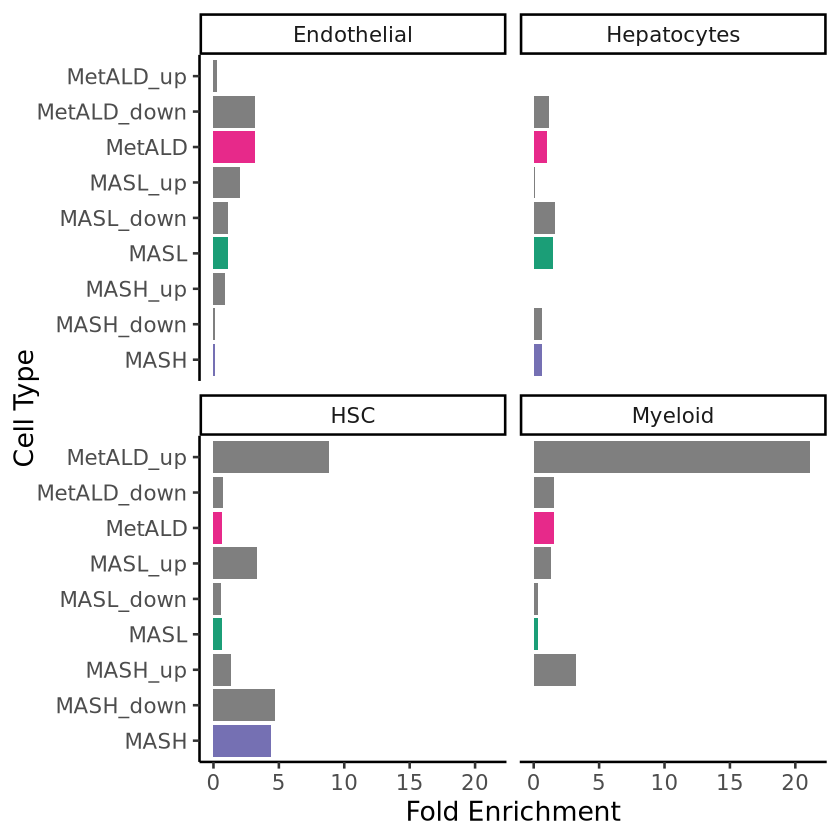

In [80]:
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241220_WE_state_FINRICH_barplot.pdf')

cluster.df.filt %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
    ggplot( aes(y=fold_enrich, x=unit, fill=unit)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6, nudge_y = .2, nudge_x=-.1) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
    scale_fill_manual(values=c(MASL="#1b9e77", MASL_specific="#2ec496", MASL_on="#48e1b5", 
                               MASH="#7570b3", MASH_specific="#9489c9", MASH_on="#b2a3df", MetALD="#e7298a")) + 
    theme(legend.position='None') + facet_wrap(. ~ Cell.Type)

#dev.off()

In [81]:
cluster.df.filt %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) 

trait,Cell.Type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper,padj,ct,lab
<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<fct>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Myeloid,MASH,1.000,0.000000000,-Infinity,-Infinity,-Infinity,1.0000000,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Myeloid,MASH_down,1.000,0.000000000,-Infinity,-Infinity,-Infinity,1.0000000,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,MASH_up,0.995,0.007152548,-4.979078167268895,-6.361861695816799,-1.4843932037665692,1.0000000,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,MetALD_up,0.570,0.012068564,-4.422506893987341,-6.636806792528734,20.908032035410617,0.8106667,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,MASL_up,0.935,0.067884540,-2.7263504766761475,-4.132434637027979,0.9107315754178109,1.0000000,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MASH_down,0.653,0.088682564,-2.4355288598304585,-4.300424556738814,7.723397360536025,0.8232000,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MASH,0.686,0.090664903,-2.4131119159868017,-4.2167730772952146,6.5998175684047595,0.8232000,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,MetALD_up,0.857,0.236296402,-1.4965308020889783,-2.682440249961978,0.7551803519549207,0.9641250,Myeloid,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Myeloid,MASL,0.608,0.327091048,-1.1388283918231878,-2.6560769784110043,3.4547819275356653,0.8106667,Myeloid,


In [82]:
cluster.df.filt.diff <- cluster.df %>%
    filter(test.group=='differential') %>%
    select(trait, Cell.Type=ct,unit, pval, fold_enrich, logOR, conf_lower, conf_upper)

Warning message:
“Removed 9 rows containing missing values or values outside the scale range (`geom_col()`).”
Warning message:
“Removed 9 rows containing missing values or values outside the scale range (`geom_text()`).”


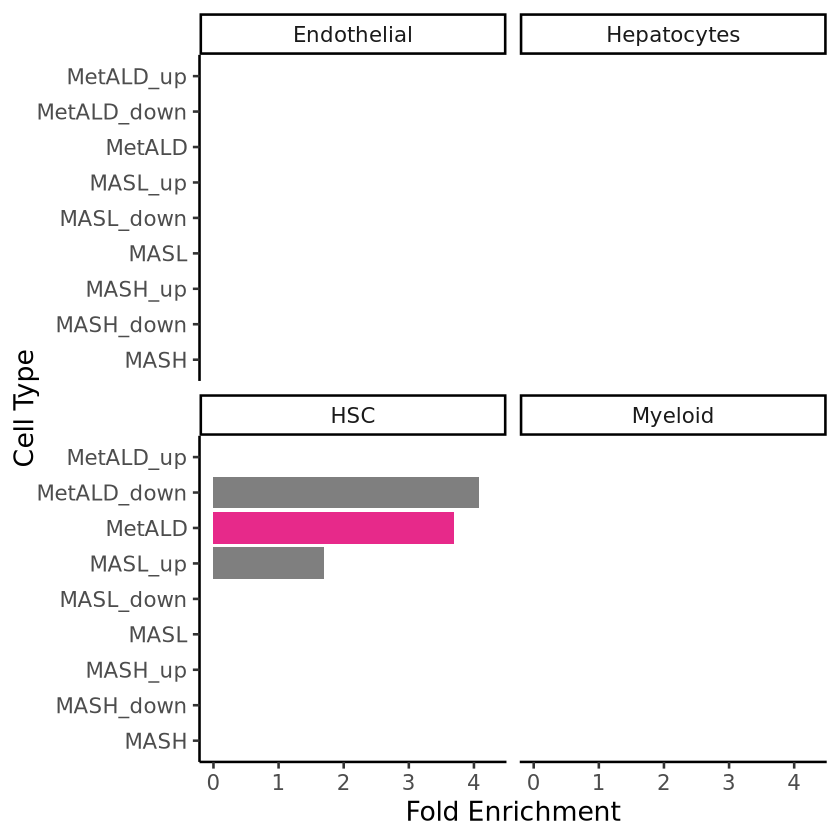

In [83]:
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241220_WE_state_differential_FINRICH_barplot.pdf')

cluster.df.filt.diff %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=ct)) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
    ggplot( aes(y=fold_enrich, x=unit, fill=unit)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6, nudge_y = .2, nudge_x=-.1) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
    scale_fill_manual(values=c(MASL="#1b9e77", MASL_specific="#2ec496", MASL_on="#48e1b5", 
                               MASH="#7570b3", MASH_specific="#9489c9", MASH_on="#b2a3df", MetALD="#e7298a")) + 
    theme(legend.position='None') + facet_wrap(. ~ Cell.Type)

#dev.off()

### GRNs

In [84]:
files[str_detect(files, 'GRN')]

[1] "T__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_MASH_GRN_Features.bed.results"
[2] "T__MVP.NAFLD.TRANS.MVP.2021.credset.bed__241221_WE_MASL_GRN_Features.bed.results"

In [89]:
out.df <- data.frame()

for (file in files[str_detect(files, 'GRN')]) {
    trait <- str_split(file, '__', simplify=T)[2]
    in.file <- str_split(file, '__', simplify=T)[3]
    
    test.group <- ifelse(str_detect(in.file,'MASH'),'MASH','MASL')
    
    res <- strsplit(readLines(paste0(out.dir.ophelia,file))[1], ":|,|}")
    res <- as.data.frame(res)
    if (length(res > 0)){
        results <- data.frame(matrix(ncol=0, nrow=1))
        results$modality <- 'ATAC'
        results$pval <- res[2,]
        results$fold_enrich <- res[4,]
        results$logOR <- res[6,]
        results$conf_lower <- res[8,]
        results$conf_upper  <- res[10,]
    }
    res <- cbind(data.frame(trait=trait, test.group=test.group), results)
    res
    
    
    out.df <- rbind(out.df, res)
}

out.df

#Endo differential - no loci in background

trait,test.group,modality,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,MASH,ATAC,0.102,2.2975851515105563,1.2249489133305471,-0.7568246942739794,4.244435229248245
MVP.NAFLD.TRANS.MVP.2021.credset.bed,MASL,ATAC,0.016,6.111055361246882,2.1437914978864607,-0.036258341659705984,13.362024292801161


In [90]:
write.table(out.df, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241221_Hep_Differential_GRNs_FINRICH.tsv',
           sep='\t',col.names=T, row.names=F, quote=F)
grn.df <- out.df

pdf 
  2

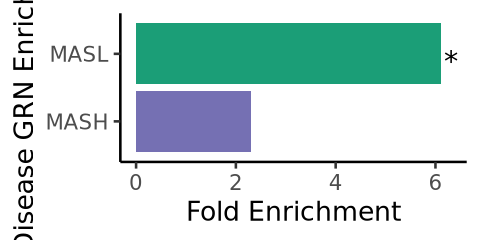

In [98]:
options(repr.plot.width=4, repr.plot.height=2)
p1 <- grn.df %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=p.adjust(pval, method='fdr')) %>%
                arrange(fold_enrich) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
    ggplot( aes(y=fold_enrich, x=test.group, fill=test.group)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6, nudge_y = .2, nudge_x=-.1) +
    labs(y='Fold Enrichment', x='Disease GRN Enriched In', fill='DESeq Direction') +
    scale_fill_manual(values=c(MASL="#1b9e77",MASH="#7570b3")) + 
    theme(legend.position='None')

p1

pdf('/nfs/lab/welison/Liver/Plots/241221_WE_GRN_FINRICH.pdf', width=4, height=2)

p1

dev.off()

### H3K27me3

In [99]:
files[grep('bins', files)]

[1] "B_H3K27me3_15kbbins_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_Fibrosis.stage.dds.res.nominal.down.bed.results"                             
  [2] "B_H3K27me3_15kbbins_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASH_ALL_vs_Control.dds.res.nominal.down.bed.results"                        
  [3] "B_H3K27me3_15kbbins_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASH_vs_Control.dds.res.nominal.down.bed.results"                            
  [4] "B_H3K27me3_15kbbins_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASL_vs_Control.dds.res.nominal.down.bed.results"                            
  [5] "B_H3K27me3_15kbbins_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MetALD_vs_Control.dds.res.nominal.down.bed.results"                          
  [6] "B_H3K27me3_15kbbins_down_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASH_ALL_vs_Control.dds.res.padj.down.bed.results"                              
  [7] "B_H3K27me3_15kbbins_down_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASH_vs_Control.dds.res.padj.down.bed.results"                                  
  [8] "B_H3K27me3_15kbbins_down_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASL_vs_Control.dds.res.padj.down.bed.results"                                  
  [9] "B_H3K27me3_15kbbins_down_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MetALD_vs_Control.dds.res.padj.down.bed.results"                                
 [10] "B_H3K27me3_15kbbins_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_Fibrosis.stage.dds.res.nominal.up.bed.results"                                 
 [11] "B_H3K27me3_15kbbins_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASH_ALL_vs_Control.dds.res.nominal.up.bed.results"                            
 [12] "B_H3K27me3_15kbbins_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASH_vs_Control.dds.res.nominal.up.bed.results"                                
 [13] "B_H3K27me3_15kbbins_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASL_vs_Control.dds.res.nominal.up.bed.results"                                
 [14] "B_H3K27me3_15kbbins_up_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MetALD_vs_Control.dds.res.nominal.up.bed.results"                              
 [15] "B_H3K27me3_15kbbins_up_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_Fibrosis.stage.dds.res.padj.up.bed.results"                                       
 [16] "B_H3K27me3_15kbbins_up_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASH_ALL_vs_Control.dds.res.padj.up.bed.results"                                  
 [17] "B_H3K27me3_15kbbins_up_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASH_vs_Control.dds.res.padj.up.bed.results"                                      
 [18] "B_H3K27me3_15kbbins_up_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MASL_vs_Control.dds.res.padj.up.bed.results"                                      
 [19] "B_H3K27me3_15kbbins_up_padj__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.B_MetALD_vs_Control.dds.res.padj.up.bed.results"                                    
 [20] "Cholangiocyte_H3K27me3_15kbbins_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.Cholangiocyte_Fibrosis.stage.dds.res.nominal.down.bed.results"     
 [21] "Cholangiocyte_H3K27me3_15kbbins_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.Cholangiocyte_MASH_ALL_vs_Control.dds.res.nominal.down.bed.results"
 [22] "Cholangiocyte_H3K27me3_15kbbins_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins.Cholangiocyte_MASH_vs_Control.dds.res.nominal.down.bed.results"    
 [23] "Cholangiocyte_H3K27me3_15kbbins_down_nominal__MVP.NAFLD.TRANS.MVP.2021.credset.bed__H3K27me3_15kbbins

In [100]:
out.df <- data.frame()

for (file in files[grep('bins', files)]) {
    test.group <- 'DESeq'
    trait <- str_split(file, '__', simplify=T)[2]
    ct <- str_split(str_split(file, '__', simplify=T)[1], '_', simplify=T)[1]
    in.file <- str_split(file, '__', simplify=T)[3]
    
    disease_condition <- ifelse(str_detect(in.file, 'Fibrosis.stage'), 'Fibrosis.stage',
                         ifelse(str_detect(in.file, 'MASH_vs_Control'), 'MASH_vs_Control',
                         ifelse(str_detect(in.file, 'MetALD_vs_Control'), 'MetALD_vs_Control',
                         ifelse(str_detect(in.file, 'MASH_ALL_vs_Control'), 'MASH_ALL_vs_Control','MASL_vs_Control'))))
            
    direction <- ifelse(str_detect(in.file, 'down'), 'down', 'up')
    Sig_level <- ifelse(str_detect(in.file, 'nominal'), 'nominal', 'padj')
    modality <- str_split(file, '__', simplify=T)[1] %>%
                    str_remove(paste0(ct,'_')) %>%
                    str_remove(paste0('_',Sig_level)) %>%
                    str_remove(paste0('_',direction))
    
    res <- strsplit(readLines(paste0(out.dir.ophelia,file))[1], ":|,|}")
    res <- as.data.frame(res)
    if (length(res > 0)){
        results <- data.frame(matrix(ncol=0, nrow=1))
        results$disease_condition <- disease_condition
        results$modality <- modality
        results$DESeq_direction <- direction
        results$Sig_level <- Sig_level
        results$cell_type <- ct
        results$unit <- test.group
        results$pval <- res[2,]
        results$fold_enrich <- res[4,]
        results$logOR <- res[6,]
        results$conf_lower <- res[8,]
        results$conf_upper  <- res[10,]
    }
    res <- cbind(data.frame(trait=trait, ct=ct, test.group=test.group), results)
    res
    
    
    out.df <- rbind(out.df, res)
}

out.df

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,H3K27me3_15kbbins,down,nominal,B,DESeq,0.011,7.768521013421499,2.0702899616737236,0.2362555274483959,12.848674512171378
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_ALL_vs_Control,H3K27me3_15kbbins,down,nominal,B,DESeq,0.058,3.024084960028315,1.1180291222849643,-0.36307599850422434,6.174169423329133
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_vs_Control,H3K27me3_15kbbins,down,nominal,B,DESeq,0.06,3.2275124494642613,1.1832151453622841,-0.3582398643947561,6.91014486794344
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASL_vs_Control,H3K27me3_15kbbins,down,nominal,B,DESeq,0.081,2.6352459103316486,0.9794394131461005,-0.4785457442725688,5.784760313012333
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MetALD_vs_Control,H3K27me3_15kbbins,down,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_ALL_vs_Control,H3K27me3_15kbbins,down,padj,B,DESeq,1.0,0.0,-Infinity,-Infinity,Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_vs_Control,H3K27me3_15kbbins,down,padj,B,DESeq,1.0,0.0,-Infinity,-Infinity,Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASL_vs_Control,H3K27me3_15kbbins,down,padj,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MetALD_vs_Control,H3K27me3_15kbbins,down,padj,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity


In [103]:
write.table(out.df, '/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241221_H3K27me3_15kb_bins_DESeq_FINRICH.tsv',
           sep='\t',col.names=T, row.names=F, quote=F)
de.df <- out.df

In [104]:
de.df

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,H3K27me3_15kbbins,down,nominal,B,DESeq,0.011,7.768521013421499,2.0702899616737236,0.2362555274483959,12.848674512171378
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_ALL_vs_Control,H3K27me3_15kbbins,down,nominal,B,DESeq,0.058,3.024084960028315,1.1180291222849643,-0.36307599850422434,6.174169423329133
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_vs_Control,H3K27me3_15kbbins,down,nominal,B,DESeq,0.06,3.2275124494642613,1.1832151453622841,-0.3582398643947561,6.91014486794344
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASL_vs_Control,H3K27me3_15kbbins,down,nominal,B,DESeq,0.081,2.6352459103316486,0.9794394131461005,-0.4785457442725688,5.784760313012333
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MetALD_vs_Control,H3K27me3_15kbbins,down,nominal,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_ALL_vs_Control,H3K27me3_15kbbins,down,padj,B,DESeq,1.0,0.0,-Infinity,-Infinity,Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_vs_Control,H3K27me3_15kbbins,down,padj,B,DESeq,1.0,0.0,-Infinity,-Infinity,Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASL_vs_Control,H3K27me3_15kbbins,down,padj,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MetALD_vs_Control,H3K27me3_15kbbins,down,padj,B,DESeq,1.0,0.0,-Infinity,-Infinity,-Infinity


In [141]:
# Cell type colors (middle brightness)
celltype_colors <- c(
  NK = "#6A0DAD",          # Medium Purple
  T = "#9B59B6",           # Light Purple
  Endothelial = "#E41A1C", # Medium Red
  Myeloid = "#FF7F00",     # Medium Orange
  B = "#8A2BE2",           # Medium Purple
  Cholangiocyte = "#FFD92F",# Choral
  HSC = "#1E90FF",         # Blue
  Mast = "#8B4513",        # Medium Yellow
  Schwann = "#808080",     # Grey
  Hepatocytes = "#4DAF4A"  # Medium Green
)

# Cell subtype colors (distinct shades)
cellsubtype_colors <- c(
  NK = "#6A0DAD",                                      # Medium Purple
  T = "#9B59B6",                                       # Light Purple
  Sinusoidal.Endothelial = "#D3372E",                  # Dark Red
  Lymphatic.Endothelial = "#FFCCBC",                   # Light Red
  Central.Vein.Endothelial = "#E46F69",                # Light Red
  Vascular.Endothelial = "#B22222",                    # Pale Red 
  Kupffer = "#CC4C02",                                 # Dark Orange
  Macrophage = "#FF7F00",                              # Orange
  Lipid.Associated.Macrophage = "#FC8D59",             # Light Orange
  B = "#8A2BE2",                                       # Medium Purple
  Plasma = "#BA55D3",                                  # Distinct Purple
  Cholangiocyte = "#FFD92F",                           # Choral
  Quescent.HSC = "#4682B4",                            # Steel Blue
  Activated.HSC = "#1E90FF",                           # Blue
  Mesenchymal = "#000080",                             # Navy
  Mast = "#8B4513",                                    # Medium Yellow
  Schwann = "#808080",                                 # Grey
  Hepatocytes.Zone1 = "#006D2C",                       # Dark Green
  Hepatocytes.Zone2 = "#4DAF4A",                       # Green
  Hepatocytes.Zone3 = "#78C679",                       # Light Green
  Hepatocytes.Senescent = "#A6D96A",                   # Pale Green
  Hepatocytes.Stress = "#D9F0A3"                       # Very Pale Green
)


In [108]:
filter(de.df, as.numeric(pval) < 0.05)

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,H3K27me3_15kbbins,down,nominal,B,DESeq,0.011,7.768521013421499,2.0702899616737236,0.2362555274483959,12.848674512171378
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,DESeq,Fibrosis.stage,H3K27me3_15kbbins,down,nominal,Cholangiocyte,DESeq,0.038,2.1145458547693674,0.7825986720584924,-0.11118415281245642,2.302761451821592
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,DESeq,MASH_vs_Control,H3K27me3_15kbbins,down,nominal,Cholangiocyte,DESeq,0.023,2.7378113228376897,1.0375141161678938,-0.04018072390616112,3.2525971292807796
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Hepatocytes,DESeq,MASL_vs_Control,H3K27me3_15kbbins,down,nominal,Hepatocytes,DESeq,0.001,2.375763649911279,0.9641836565961244,0.30423450831134025,1.8684944947615012
MVP.NAFLD.TRANS.MVP.2021.credset.bed,HSC,DESeq,MASH_ALL_vs_Control,H3K27me3_15kbbins,down,padj,HSC,DESeq,0.01,46.23732800502536,3.8503766728332627,1.5543351426704481,175.58151815546046
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Myeloid,DESeq,MASL_vs_Control,H3K27me3_15kbbins,down,nominal,Myeloid,DESeq,0.033,2.818169538493921,1.060230699482825,-0.10774594161151296,3.7204764016519634
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Myeloid,DESeq,Fibrosis.stage,H3K27me3_15kbbins,up,nominal,Myeloid,DESeq,0.0,3.18120981846982,1.2707274331948348,0.5561881975018139,2.307702239290008
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Myeloid,DESeq,MASH_ALL_vs_Control,H3K27me3_15kbbins,up,nominal,Myeloid,DESeq,0.0,4.034999120458589,1.4999297634208708,0.6359684968895574,2.9275362504274827
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Myeloid,DESeq,MASH_vs_Control,H3K27me3_15kbbins,up,nominal,Myeloid,DESeq,0.0,3.317266270273535,1.2588087218660629,0.3141246594412488,2.9501101155453586


In [107]:
filter(de.df, disease_condition=='Fibrosis.stage' & Sig_level=='padj') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=unique(ct))) %>%
                mutate(lab=ifelse(padj < 0.05, '*',''))

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper,padj,lab
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,H3K27me3_15kbbins,up,padj,B,DESeq,1.000,0.0000000,-Infinity,-Infinity,Infinity,1.000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,DESeq,Fibrosis.stage,H3K27me3_15kbbins,down,padj,Cholangiocyte,DESeq,1.000,0.0000000,-Infinity,-Infinity,-Infinity,1.000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,DESeq,Fibrosis.stage,H3K27me3_15kbbins,up,padj,Cholangiocyte,DESeq,1.000,0.0000000,-Infinity,-Infinity,-Infinity,1.000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,DESeq,Fibrosis.stage,H3K27me3_15kbbins,down,padj,Endothelial,DESeq,1.000,0.0000000,-Infinity,-Infinity,-Infinity,1.000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Endothelial,DESeq,Fibrosis.stage,H3K27me3_15kbbins,up,padj,Endothelial,DESeq,1.000,0.0000000,-Infinity,-Infinity,-Infinity,1.000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,HSC,DESeq,Fibrosis.stage,H3K27me3_15kbbins,down,padj,HSC,DESeq,1.000,0.0000000,-Infinity,-Infinity,-Infinity,1.000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,HSC,DESeq,Fibrosis.stage,H3K27me3_15kbbins,up,padj,HSC,DESeq,1.000,0.0000000,-Infinity,-Infinity,-Infinity,1.000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,NK,DESeq,Fibrosis.stage,H3K27me3_15kbbins,up,padj,NK,DESeq,1.000,0.0000000,-Infinity,-Infinity,Infinity,1.000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,T,DESeq,Fibrosis.stage,H3K27me3_15kbbins,down,padj,T,DESeq,1.000,0.0000000,-Infinity,-Infinity,Infinity,1.000,


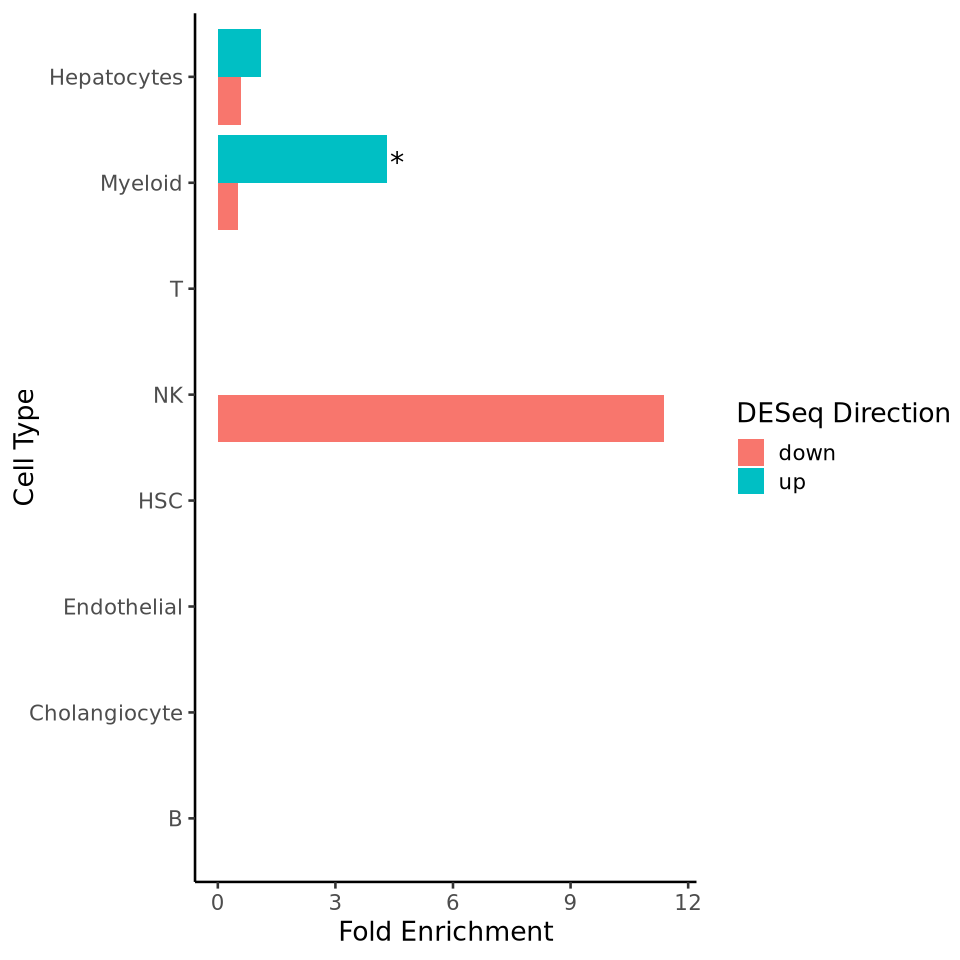

In [116]:
options(repr.plot.width=8, repr.plot.height=8)
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_fibrosis_stage_ATAC_barplot.pdf')

filter(de.df, disease_condition=='Fibrosis.stage' & Sig_level=='padj') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=unique(ct))) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>%
            ggplot(aes(y=fold_enrich, x=ct, fill=DESeq_direction)) + 
    geom_col(position = "dodge") + 
    theme_classic(base_size=16) + coord_flip() + 
    geom_text(aes(label = lab), size=6 , nudge_y = 0.25, nudge_x=.2) +
    labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction')

#dev.off()

In [117]:
filter(de.df, Sig_level=='padj') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                group_by(disease_condition) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=unique(ct))) %>%
                mutate(lab=ifelse(padj < 0.05, '*',''))

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper,padj,lab
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_ALL_vs_Control,H3K27me3_15kbbins,down,padj,B,DESeq,1,0,-Infinity,-Infinity,Infinity,1,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_vs_Control,H3K27me3_15kbbins,down,padj,B,DESeq,1,0,-Infinity,-Infinity,Infinity,1,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASL_vs_Control,H3K27me3_15kbbins,down,padj,B,DESeq,1,0,-Infinity,-Infinity,-Infinity,1,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MetALD_vs_Control,H3K27me3_15kbbins,down,padj,B,DESeq,1,0,-Infinity,-Infinity,-Infinity,1,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,H3K27me3_15kbbins,up,padj,B,DESeq,1,0,-Infinity,-Infinity,Infinity,1,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_ALL_vs_Control,H3K27me3_15kbbins,up,padj,B,DESeq,1,0,-Infinity,-Infinity,-Infinity,1,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_vs_Control,H3K27me3_15kbbins,up,padj,B,DESeq,1,0,-Infinity,-Infinity,-Infinity,1,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASL_vs_Control,H3K27me3_15kbbins,up,padj,B,DESeq,1,0,-Infinity,-Infinity,Infinity,1,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MetALD_vs_Control,H3K27me3_15kbbins,up,padj,B,DESeq,1,0,-Infinity,-Infinity,-Infinity,1,


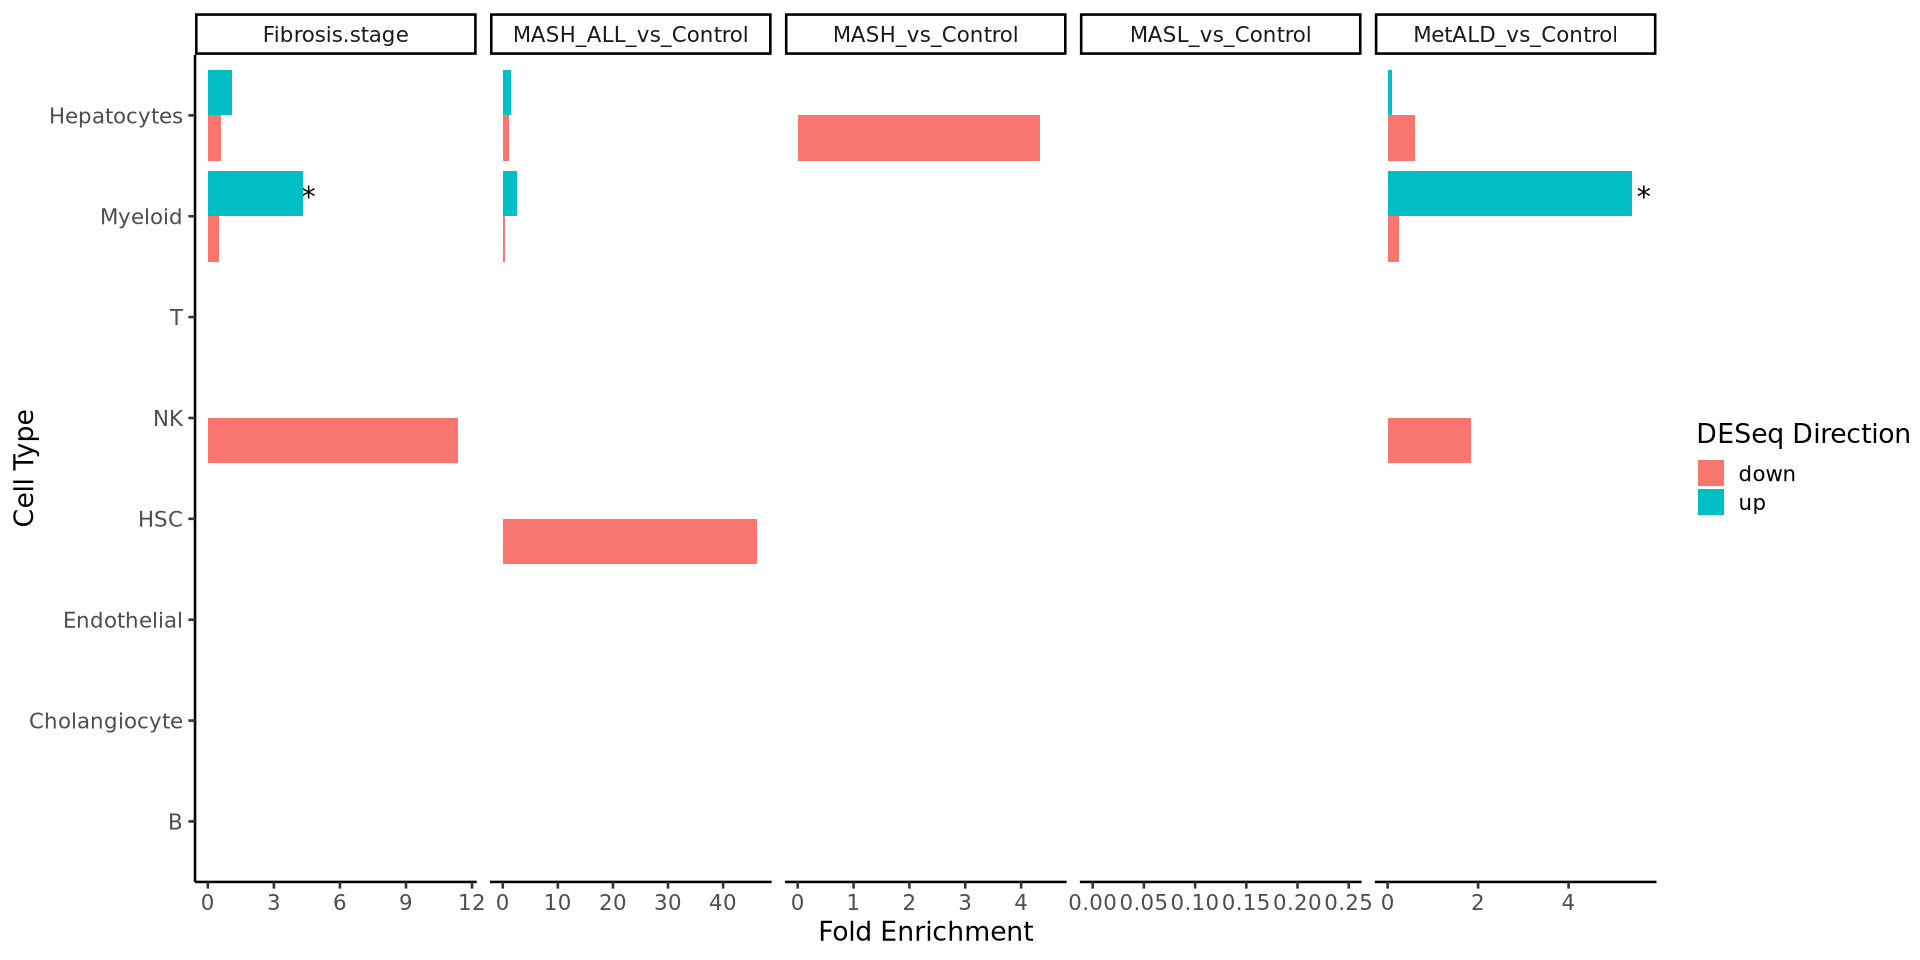

In [124]:
options(repr.plot.width=16, repr.plot.height=8)
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_fibrosis_stage_ATAC_barplot.pdf')

filter(de.df, Sig_level=='padj') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                group_by(disease_condition) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=unique(ct))) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>% 
    ggplot(aes(y=fold_enrich, x=ct, fill=DESeq_direction)) + 
        geom_col(position = "dodge") + 
        theme_classic(base_size=16) + coord_flip() + 
        geom_text(aes(label = lab), size=6 , nudge_y = 0.25, nudge_x=.2) +
        labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
        facet_wrap(. ~ disease_condition, ncol = 6, scales='free_x')

#dev.off()

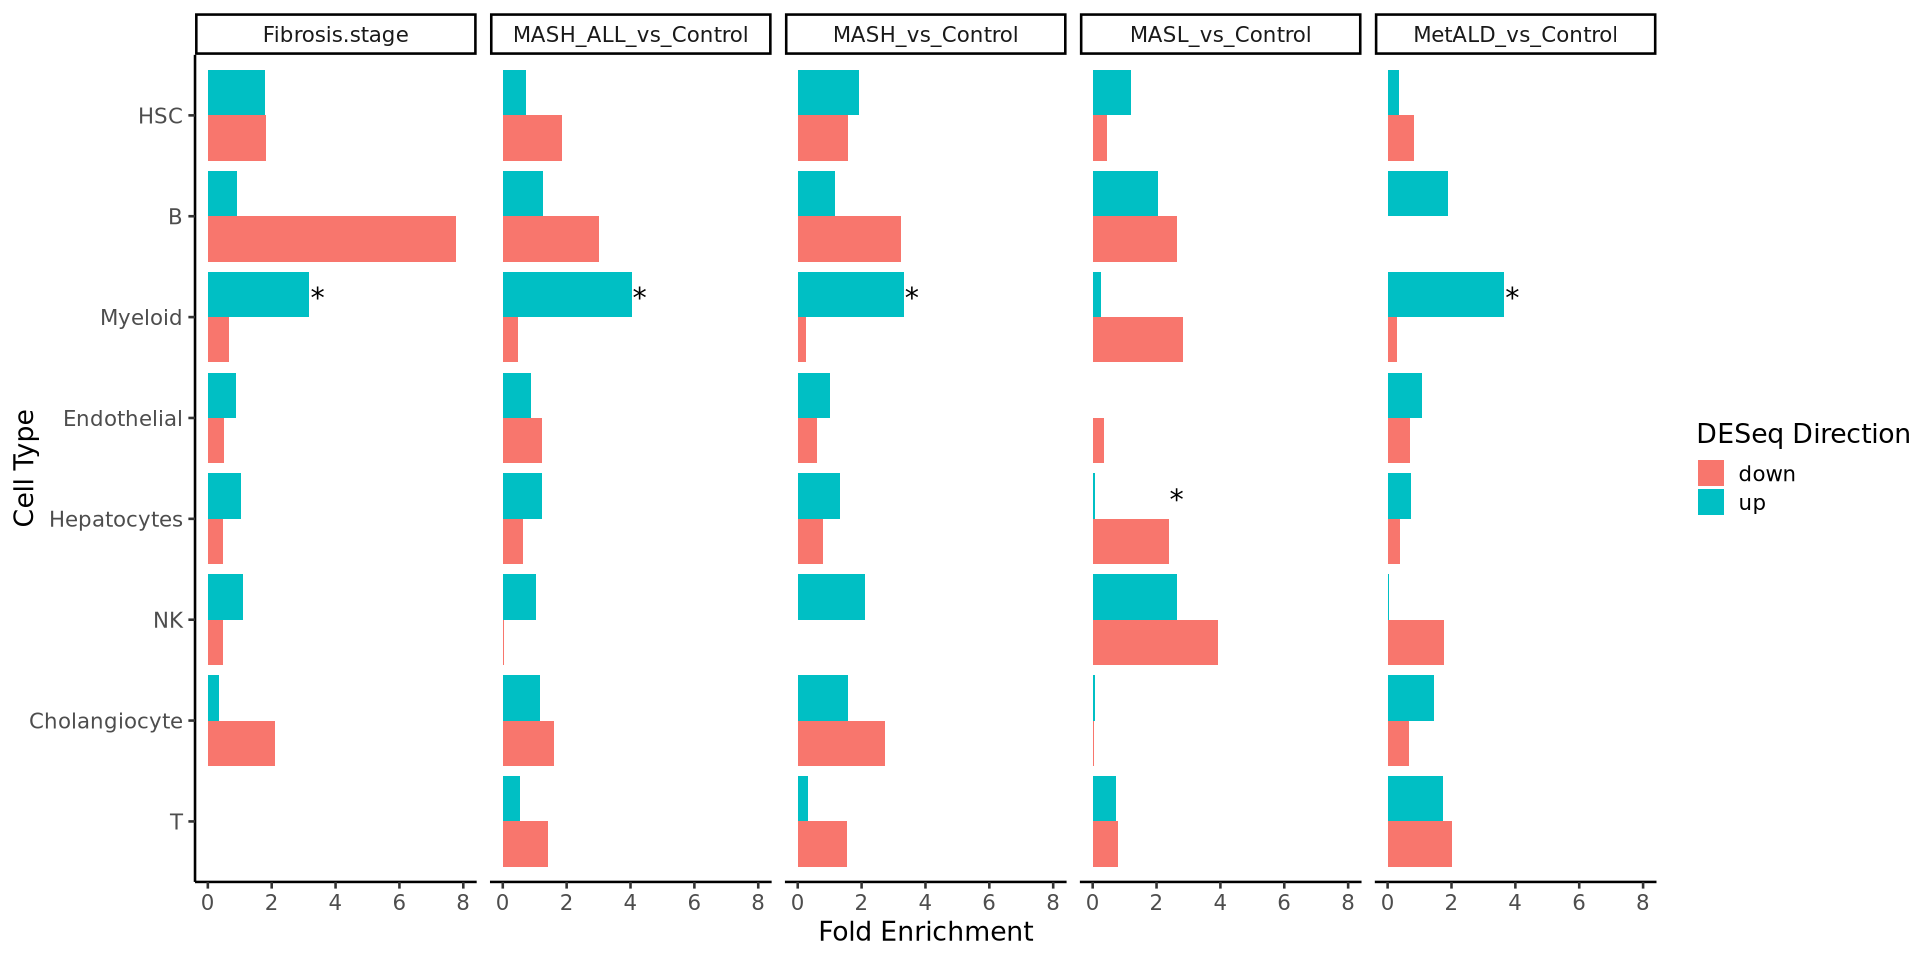

In [123]:
options(repr.plot.width=16, repr.plot.height=8)
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_fibrosis_stage_ATAC_barplot.pdf')

filter(de.df, Sig_level=='nominal') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                group_by(disease_condition) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=unique(ct))) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>% 
    ggplot(aes(y=fold_enrich, x=ct, fill=DESeq_direction)) + 
        geom_col(position = "dodge") + 
        theme_classic(base_size=16) + coord_flip() + 
        geom_text(aes(label = lab), size=6 , nudge_y = 0.25, nudge_x=.2) +
        labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
        facet_wrap(. ~ disease_condition, ncol = 6)

#dev.off()

In [126]:
de.full <- read.table('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_5k_DESeq_FINRICH.tsv', header=T)

dim(de.full)
head(de.full)

[1] 753  14

,trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,ATAC,down,nominal,B,DESeq,1,0,-Inf,-Inf,-Inf
2,MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_ALL_vs_Control,ATAC,down,nominal,B,DESeq,1,0,-Inf,-Inf,-Inf
3,MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASH_vs_Control,ATAC,down,nominal,B,DESeq,1,0,-Inf,-Inf,-Inf
4,MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MASL_vs_Control,ATAC,down,nominal,B,DESeq,1,0,-Inf,-Inf,-Inf
5,MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MetALD_vs_Control,ATAC,down,nominal,B,DESeq,1,0,-Inf,-Inf,-Inf
6,MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,ATAC,down,padj,B,DESeq,1,0,-Inf,-Inf,Inf


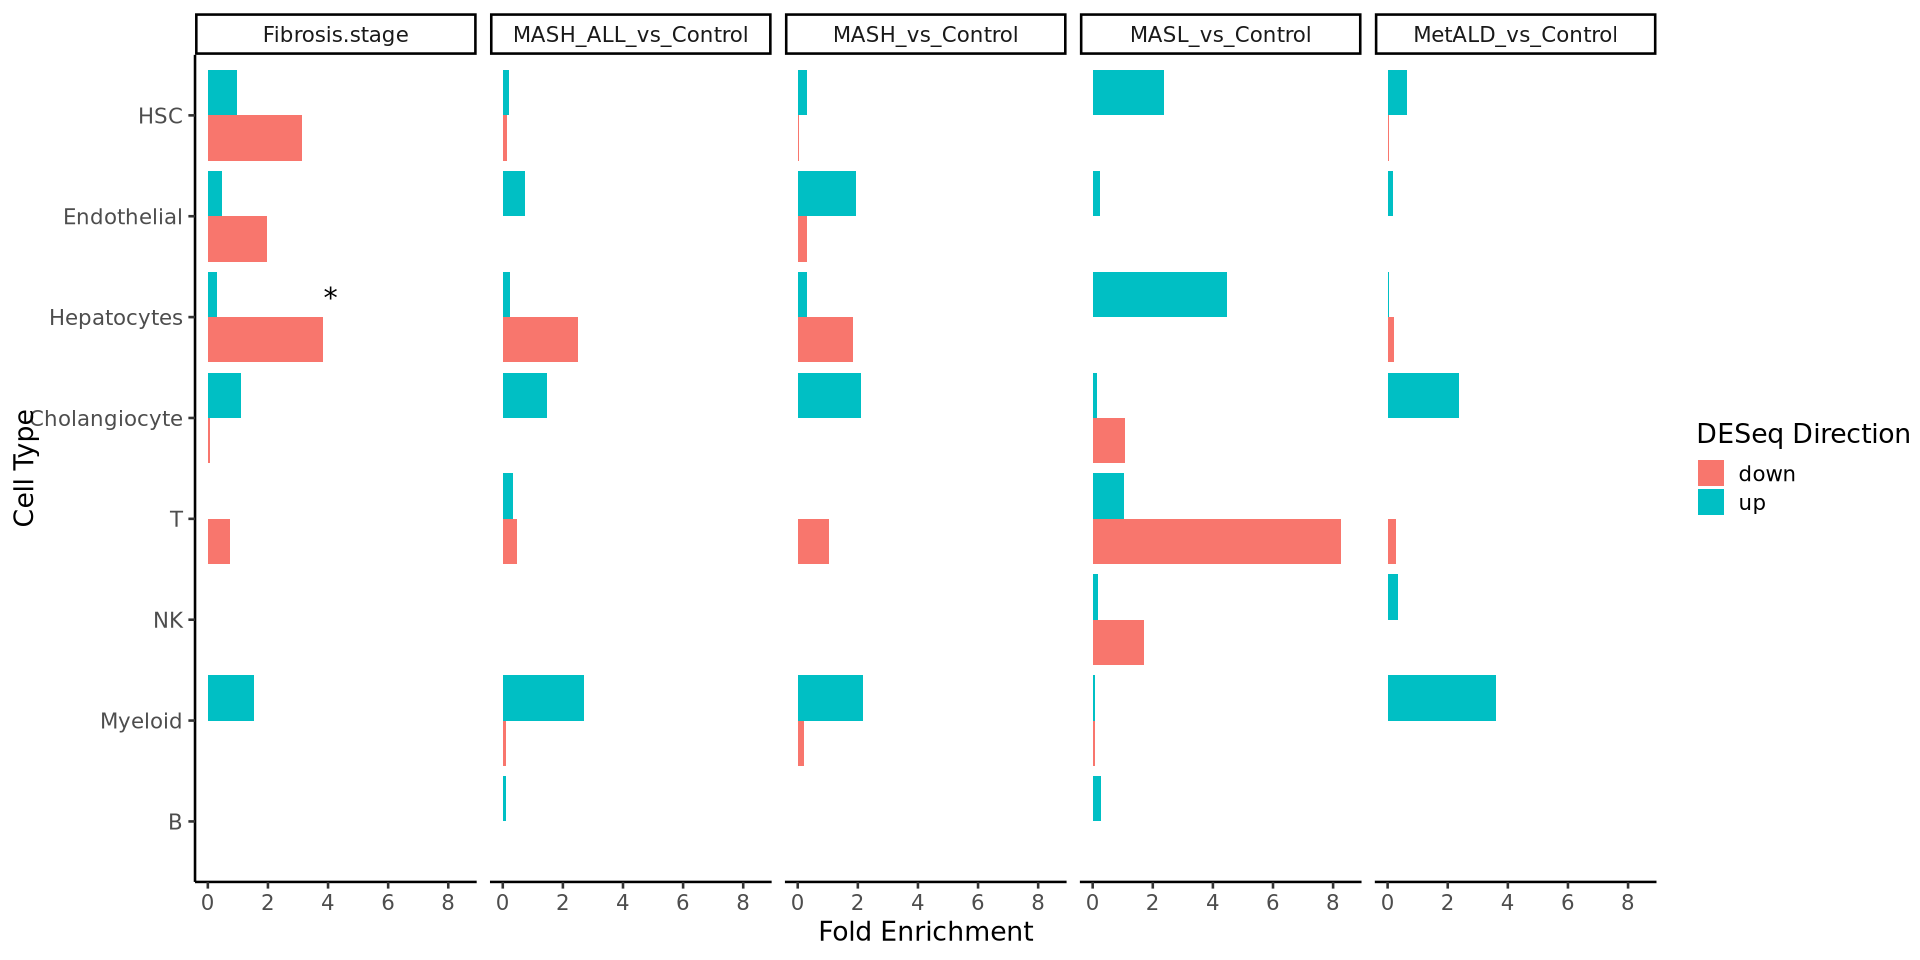

In [128]:
options(repr.plot.width=16, repr.plot.height=8)
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_fibrosis_stage_ATAC_barplot.pdf')

filter(de.full, Sig_level=='nominal' & modality=='ATAC') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                group_by(disease_condition) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=unique(ct))) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>% 
    ggplot(aes(y=fold_enrich, x=ct, fill=DESeq_direction)) + 
        geom_col(position = "dodge") + 
        theme_classic(base_size=16) + coord_flip() + 
        geom_text(aes(label = lab), size=6 , nudge_y = 0.25, nudge_x=.2) +
        labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
        facet_wrap(. ~ disease_condition, ncol = 6)

#dev.off()

In [132]:
filter(de.full, Sig_level=='padj' & modality=='ATAC' & disease_condition != 'MASL_vs_Control') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                group_by(disease_condition) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=unique(ct))) %>%
                mutate(lab=ifelse(padj < 0.05, '*',''))

trait,ct,test.group,disease_condition,modality,DESeq_direction,Sig_level,cell_type,unit,pval,fold_enrich,logOR,conf_lower,conf_upper,padj,lab
<chr>,<fct>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,ATAC,down,padj,B,DESeq,1.000,0.00000000,-Inf,-Inf,Inf,1.0000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,MetALD_vs_Control,ATAC,down,padj,B,DESeq,1.000,0.00000000,-Inf,-Inf,Inf,1.0000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,B,DESeq,Fibrosis.stage,ATAC,up,padj,B,DESeq,1.000,0.00000000,-Inf,-Inf,Inf,1.0000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,DESeq,Fibrosis.stage,ATAC,down,padj,Cholangiocyte,DESeq,1.000,0.00000000,-Inf,-Inf,-Inf,1.0000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,DESeq,MASH_ALL_vs_Control,ATAC,down,padj,Cholangiocyte,DESeq,1.000,0.00000000,-Inf,-Inf,-Inf,1.0000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,DESeq,MASH_vs_Control,ATAC,down,padj,Cholangiocyte,DESeq,1.000,0.00000000,-Inf,-Inf,Inf,1.0000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,DESeq,MetALD_vs_Control,ATAC,down,padj,Cholangiocyte,DESeq,1.000,0.00000000,-Inf,-Inf,Inf,1.0000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,DESeq,MASH_vs_Control,ATAC,up,padj,Cholangiocyte,DESeq,1.000,0.00000000,-Inf,-Inf,-Inf,1.0000,
MVP.NAFLD.TRANS.MVP.2021.credset.bed,Cholangiocyte,DESeq,MetALD_vs_Control,ATAC,up,padj,Cholangiocyte,DESeq,1.000,0.00000000,-Inf,-Inf,-Inf,1.0000,


Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_col()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range (`geom_text()`).”


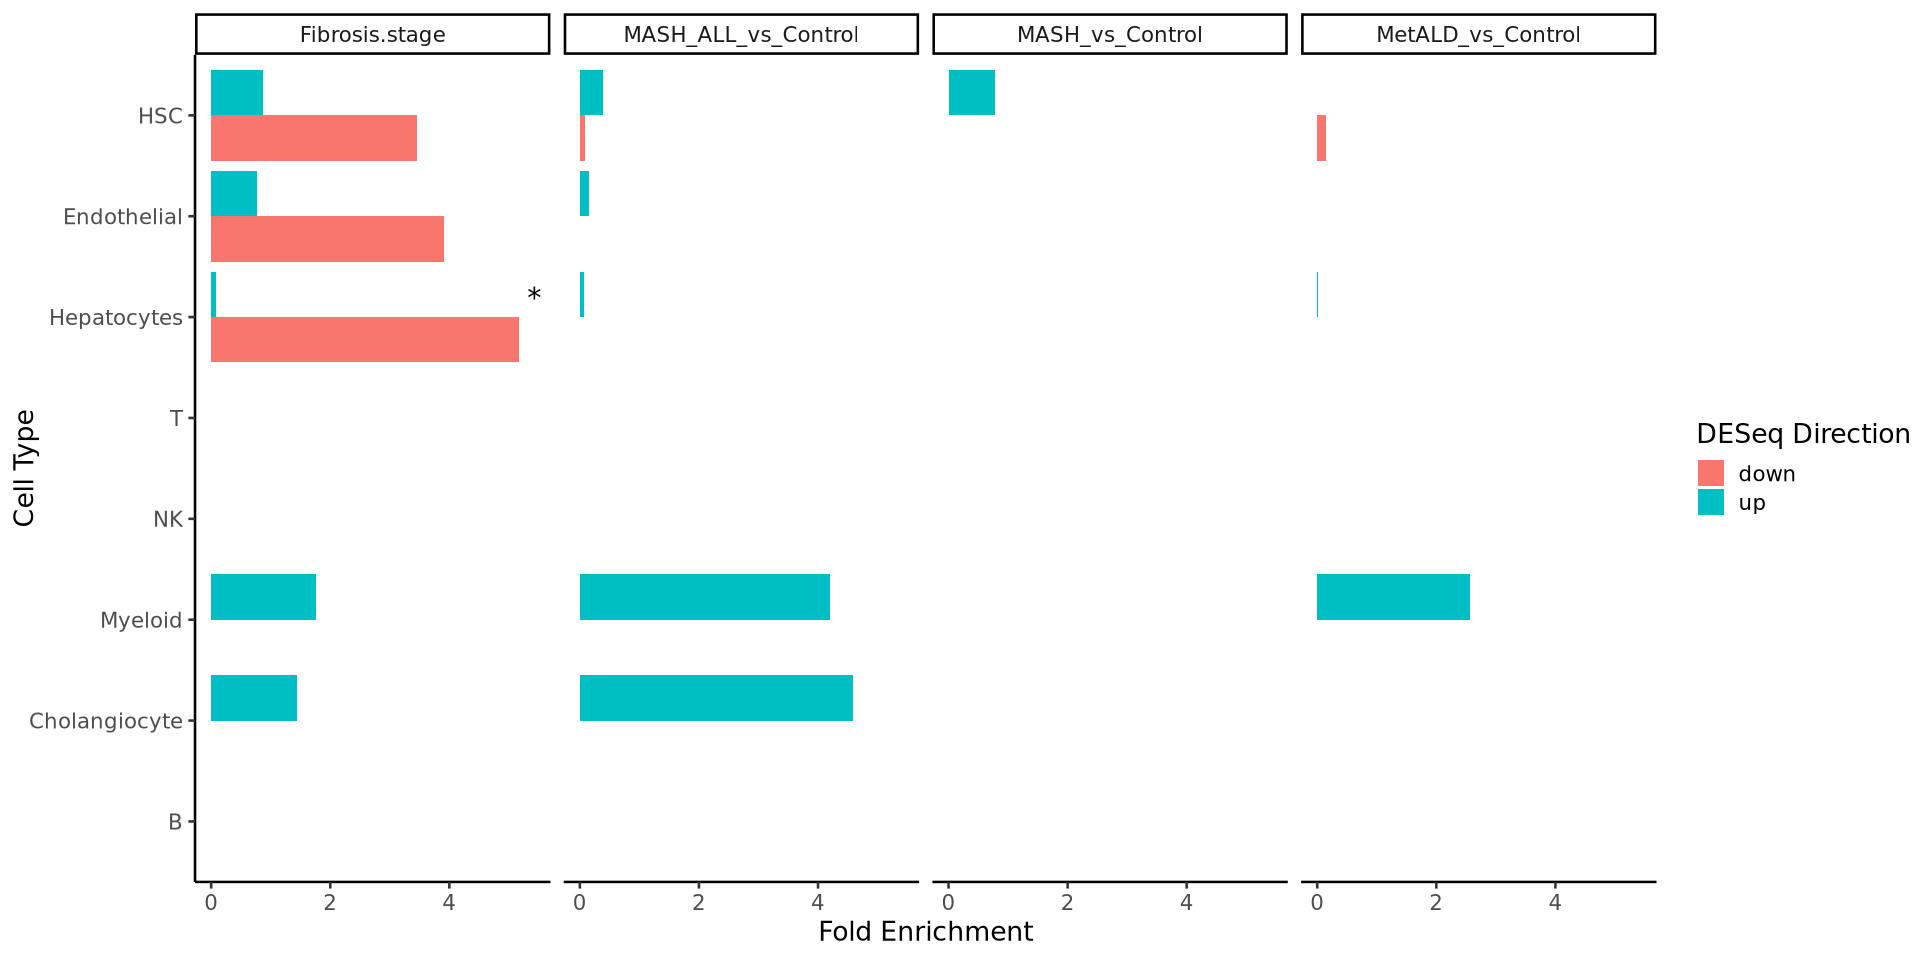

In [133]:
options(repr.plot.width=16, repr.plot.height=8)
#pdf('/nfs/lab/tscc/welison/FNIH.Liver/11_FINRICH/results/241218_WE_fibrosis_stage_ATAC_barplot.pdf')

filter(de.full, Sig_level=='padj' & modality=='ATAC' & disease_condition != 'MASL_vs_Control') %>%
                mutate(pval = as.numeric(pval), fold_enrich=as.numeric(fold_enrich)) %>%
                group_by(disease_condition) %>%
                mutate(padj=qvalue(pval)$qvalues) %>%
                arrange(fold_enrich) %>%
                mutate(ct=factor(ct, levels=unique(ct))) %>%
                mutate(lab=ifelse(padj < 0.05, '*','')) %>% 
    ggplot(aes(y=fold_enrich, x=ct, fill=DESeq_direction)) + 
        geom_col(position = "dodge") + 
        theme_classic(base_size=16) + coord_flip() + 
        geom_text(aes(label = lab), size=6 , nudge_y = 0.25, nudge_x=.2) +
        labs(y='Fold Enrichment', x='Cell Type', fill='DESeq Direction') +
        facet_wrap(. ~ disease_condition, ncol = 6)

#dev.off()